# 01 - Dataset analysis

Load the raw URL dataset, clean it, and inspect the class distribution.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)

In [2]:
from config.config import RAW_DATASET, EXTERNAL_DATASET
from app.ml.preprocessing import load_raw_dataset, clean_dataset, class_distribution

raw = load_raw_dataset(RAW_DATASET)
print(f'{len(raw)} rows loaded from {RAW_DATASET.name}')
raw.head()

15635 rows loaded from urls.csv


,url,label
0,http://unlock.2mgbcm6bfut0r.online/secure/reco...,phishing
1,https://update.maplebridge.cf/payment/password...,phishing
2,http://payment.apple7988.co/contact,phishing
3,https://storeorbit.info/posts/developers/billi...,legitimate
4,https://ieee.org/search/pricing.aspx,legitimate


In [3]:
cleaned = clean_dataset(raw)
print(f'{len(cleaned)} rows after cleaning ({len(raw) - len(cleaned)} dropped)')
class_distribution(cleaned)

2026-09-26 13:12:04 | INFO     | app.ml.preprocessing | Cleaned dataset: 15635 rows kept out of 15635


15635 rows after cleaning (0 dropped)


{'legitimate': 8440, 'phishing': 7195, 'total': 15635}

## Class balance

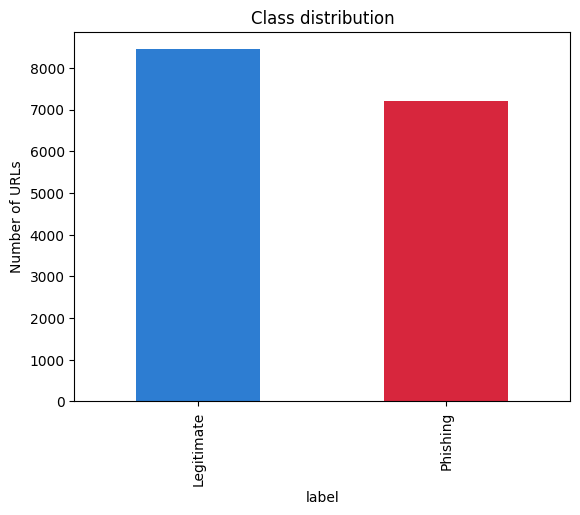

In [4]:
counts = cleaned['label'].map({0: 'Legitimate', 1: 'Phishing'}).value_counts()
counts.plot(kind='bar', color=['#2d7dd2', '#d7263d'])
plt.title('Class distribution')
plt.ylabel('Number of URLs')
plt.show()

## URL length by class (a first look at separability)

In [5]:
cleaned['length'] = cleaned['url'].str.len()
cleaned.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8440.0,50.253791,26.911881,13.0,31.0,42.0,61.0,167.0
1,7195.0,76.066852,33.812203,14.0,48.0,71.0,102.0,184.0


The two classes overlap on simple statistics such as raw length; see notebook 02 for the full engineered feature set.